In [4]:
import os, random, pickle
import numpy as np, pandas as pd, re
import nltk
from nltk.corpus import wordnet, stopwords
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HOSSAM\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HOSSAM\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HOSSAM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<!-- 
import os
os = Operating System library
Used to control OS settings → later used to fix random seed.

✔️ import random
Python's built-in random number generator.
Used for text augmentation and reproducibility.

✔️ import pickle
Used to save Python objects.
We use pickle to save:
the tokenizer (tokenizer.pkl)
the label encoder (label_encoder.pkl)

numpy → for numbers
➡️ pandas → read CSV files
➡️ re → cleaning text using regex
➡️ nltk → for text processing
➡️ wordnet → to find synonyms (for augmentation)
➡️ stopwords → list of useless words like “the, a, an, is…” 

wordnet → used to generate synonyms
omw-1.4 → WordNet language support
stopwords → list of words to ignore during cleaning
-->


<!--setting a fixed seed makes ALL randomness constant.
So your model always trains exactly the same way.

✔️ SEED = 42
We choose any number (usually 42).
42 is famous in programming as a “universal seed”.

✔️ os.environ['PYTHONHASHSEED'] = str(SEED)
Python internally randomizes dictionary order using a hash seed.
This line forces Python itself to use fixed hashing so EVERYTHING becomes reproducible.


os.environ = environment variables
['PYTHONHASHSEED'] = key of the variable
str(SEED) = convert integer 42 → "42"

✔️ random.seed(SEED)
This sets the seed for Python’s built-in random module.
Used in:
data sampling
selecting random words for augmentation
shuffling
Without this → augmentation changes every run → accuracy changes.

✔️ np.random.seed(SEED)
Sets the seed for numpy random number generator.
Used in:
padding
tokenizer ordering
any numpy randomness

👉 Together, these 3 seeds make the whole experiment 100% repeatable.
Without them, your validation accuracy will change each time you run.
With them, your work becomes stable and scientifically valid. -->

In [2]:
# Cell 1: Load data and inspect
df = pd.read_csv("train.csv")    # ensure the file is present
print("Shape:", df.shape)
display(df.head(6))
print("\nLabel distribution:")
print(df['review'].value_counts())


Shape: (7000, 3)


,id,text,review
0,7961,Honestly the best part of this place is the un...,Excellent
1,4697,"Found Indulge on a whim, based on their huge ""...",Excellent
2,4459,My take on Mill street is that it's your class...,Very good
3,3714,I think Matt's has had its '5 minutes of fame'...,Bad
4,4744,Nobody likes going to the auto body shop..peri...,Excellent
5,872,"On my way to the Airport, I decided to stop at...",Good



Label distribution:
review
Very good    2469
Excellent    2335
Good         1024
Bad           648
Very bad      524
Name: count, dtype: int64


In [3]:
# Cell 2: cleaning and label encoding
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9.,!?'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)

# encode labels and save encoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['review'])
with open("label_encoder.pkl","wb") as f: pickle.dump(le, f)

print("Classes:", list(le.classes_))


Classes: ['Bad', 'Excellent', 'Good', 'Very bad', 'Very good']


<!-- text = re.sub(r"[^a-z0-9.,!?'\s]", " ", text)
This removes anything except:
letters a–z
digits 0–9
punctuation: .,!?‘
whitespace

text = re.sub(r"\s+", " ", text).strip()
Replace multiple spaces with one
Remove spaces at start/end

Apply cleaning to whole dataset
df['text_clean'] = df['text'].apply(clean_text)

Creates new column "text_clean" -->

In [4]:
# ---------------------------
# Cell 3 (Optimized): Balance classes with augmentation
# ---------------------------
from random import choice, sample
# choice(list) → selects one random element from a list.
# sample(list, n) → selects n unique random elements from a list.

#n_swaps=1 → default argument, number of words to replace if not specified.
def synonym_swap(sentence, n_swaps=1):
    words = sentence.split()
    # .split() → splits a string into a list of words, splitting at spaces.
    # Example: "I love cats" → ['I', 'love', 'cats']

    if len(words) < 2: 
        return sentence
    
    idxs = sample(range(len(words)), min(n_swaps, len(words)))

    # range(len(words)) → creates a list of indices [0, 1, ..., n-1] where n = number of words.
    # min(n_swaps, len(words)) → ensures you don’t swap more words than exist.
    # sample(...) → picks random indices of words to replace.





    # Loop over the indices picked to swap.
    # w = words[i] → store the word at that index.
    for i in idxs:
        w = words[i]
        
        syns = set()
        #Create an empty set to store synonyms.

        for ss in nltk.corpus.wordnet.synsets(w):
            for l in ss.lemmas():
                syn = l.name().replace('_',' ')
                if syn != w:
                    syns.add(syn)
        if syns:
            words[i] = choice(list(syns))
        #if syns: → if we found at least one synonym.
        # choice(list(syns)) → pick one random synonym.
        # words[i] = ... → replace the original word with the synonym.  
          
    return " ".join(words)
    # " ".join(words) → join the list of words back into a single string with spaces.

# target count = max class
target_count = df['label'].value_counts().max()
print("Target count per class:", target_count)

aug_rows = []

for label, count in df['label'].value_counts().items():
    need = target_count - count
    if need <= 0:
        continue
    samples = df[df['label']==label].sample(n=need, replace=True, random_state=SEED)
    for _, r in samples.iterrows():
        aug_text = synonym_swap(r['text_clean'], n_swaps=4)
        aug_rows.append({'text': r['text'], 'text_clean': aug_text, 'review': r['review'], 'label': r['label']})

if aug_rows:
    df = pd.concat([df, pd.DataFrame(aug_rows)], ignore_index=True)

print("Label counts after augmentation:")
print(df['label'].value_counts().to_dict())


Target count per class: 2469
Label counts after augmentation:
{1: 2469, 4: 2469, 0: 2469, 2: 2469, 3: 2469}


<!-- 
 for ss in nltk.corpus.wordnet.synsets(w):
            for l in ss.lemmas():
                syn = l.name().replace('_',' ')
                if syn != w:
                    syns.add(syn) 
                    
                    
nltk.corpus.wordnet.synsets(w) → gets all synonym sets of w.
ss.lemmas() → gets words in the synonym set.

l.name() → the text of the synonym.
.replace('_',' ') → convert multi_word_synonym → "multi word synonym"
if syn != w: → don’t include the original word itself.
syns.add(syn) → add the synonym to the set                   
                    
                    
                    -->

In [ ]:
# Cell 4: split
X = df['text_clean']
y = df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print("Train / Val:", X_train.shape, X_val.shape)


Train / Val: (9876,) (2469,)


In [6]:
# Cell 5: tokenizer & pad sequences
max_words = 20000
max_len = 150

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

vocab_size = min(max_words, len(tokenizer.word_index) + 1)
print("Vocab size used:", vocab_size)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_len, padding='post', truncating='post')

# save tokenizer
with open("tokenizer.pkl","wb") as f: pickle.dump(tokenizer, f)


Vocab size used: 20000


In [7]:
# Cell 6: baseline TF-IDF + Logistic
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
clf = LogisticRegression(max_iter=400, class_weight='balanced', random_state=SEED)
pipe = Pipeline([('tfidf', tfidf), ('clf', clf)])

pipe.fit(X_train, y_train)
y_val_pred = pipe.predict(X_val)
print("Baseline TF-IDF Logistic accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=le.classes_))
# Keep this probability predictions for ensemble later
proba_val_tfidf = pipe.predict_proba(X_val)


Baseline TF-IDF Logistic accuracy: 0.766302146618064
              precision    recall  f1-score   support

         Bad       0.90      0.91      0.91       494
   Excellent       0.63      0.68      0.66       493
        Good       0.81      0.80      0.81       494
    Very bad       0.89      0.96      0.92       494
   Very good       0.56      0.48      0.52       494

    accuracy                           0.77      2469
   macro avg       0.76      0.77      0.76      2469
weighted avg       0.76      0.77      0.76      2469



In [8]:
# ---------------------------
# Compute class weights
# ---------------------------
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, class_weights))
print("Class weights:", class_weights)


Class weights: {np.int64(0): np.float64(1.0001012658227848), np.int64(1): np.float64(0.9995951417004049), np.int64(2): np.float64(1.0001012658227848), np.int64(3): np.float64(1.0001012658227848), np.int64(4): np.float64(1.0001012658227848)}


In [9]:
import matplotlib.pyplot as plt

# ---------------------------
# CNN model
# ---------------------------
embedding_dim_cnn = 128
filters = 100
kernel_size = 5
dense_units_cnn = 64
dropout_rate_cnn = 0.6

model_cnn = models.Sequential([
    layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim_cnn, input_length=max_len),
    layers.Conv1D(filters=filters, kernel_size=kernel_size, padding='same', activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(filters=filters, kernel_size=3, padding='same', activation='relu'),
    layers.GlobalMaxPool1D(),
    layers.Dense(dense_units_cnn, activation='relu'),
    layers.Dropout(dropout_rate_cnn),
    layers.Dense(len(le.classes_), activation='softmax')
])

model_cnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    metrics=['accuracy']
)

model_cnn.summary()


c:\Users\yasmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ---------------------------
# Train CNN
# ---------------------------
callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
]

history_cnn = model_cnn.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks_cnn
)

# Save model
model_cnn.save("cnn_model.keras")

# Evaluate on validation
val_loss_cnn, val_acc_cnn = model_cnn.evaluate(X_val_pad, y_val, verbose=0)
print("CNN Validation Accuracy:", val_acc_cnn)


Epoch 1/15
155/155 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.2467 - loss: 1.6014 - val_accuracy: 0.3961 - val_loss: 1.5878
Epoch 2/15
155/155 ━━━━━━━━━━━━━━━━━━━━ 18s 82ms/step - accuracy: 0.3877 - loss: 1.5355 - val_accuracy: 0.4508 - val_loss: 1.4390
Epoch 3/15
155/155 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.4999 - loss: 1.2462 - val_accuracy: 0.5691 - val_loss: 1.1021
Epoch 4/15
155/155 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.6281 - loss: 0.9159 - val_accuracy: 0.6784 - val_loss: 0.8418
Epoch 5/15
155/155 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.7390 - loss: 0.6597 - val_accuracy: 0.7331 - val_loss: 0.6736
Epoch 6/15
155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8080 - loss: 0.4873 - val_accuracy: 0.7513 - val_loss: 0.6122
Epoch 7/15
155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8548 - loss: 0.3837 - val_accuracy: 0.7623 - val_loss: 0.5827
Epoch 8/15
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8918 - loss: 0.3051 - va

CNN Validation Accuracy: 0.7703523635864258
CNN Validation Loss: 0.6755615472793579


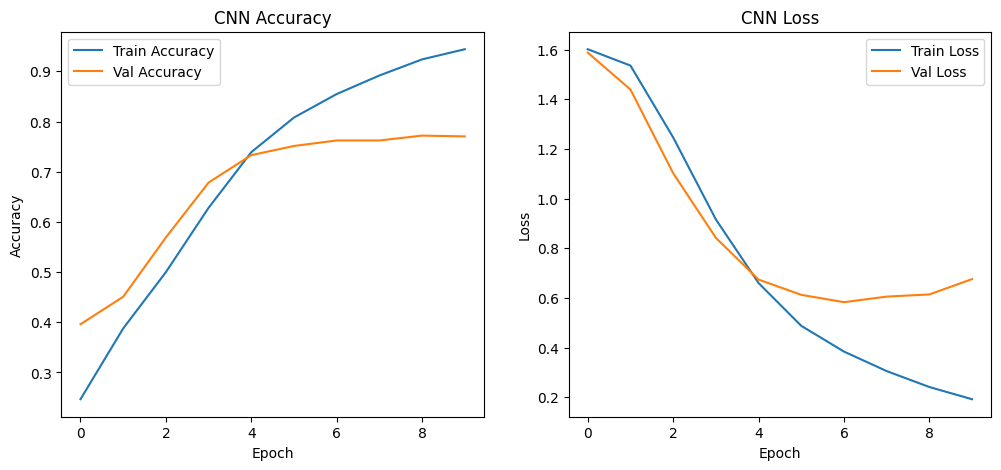

In [11]:
# CNN final validation accuracy and loss
final_val_acc_cnn = history_cnn.history['val_accuracy'][-1]
final_val_loss_cnn = history_cnn.history['val_loss'][-1]

print("CNN Validation Accuracy:", final_val_acc_cnn)
print("CNN Validation Loss:", final_val_loss_cnn)

# Plot accuracy and loss
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [12]:
from tensorflow.keras import layers
import tensorflow as tf

class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, max_len, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.max_len = max_len
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        # token embedding
        self.token_emb = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            mask_zero=False,
            name="token_embedding"
        )
        # learned position embeddings for positions 0..max_len-1
        self.pos_emb = layers.Embedding(
            input_dim=max_len,
            output_dim=embed_dim,
            name="pos_embedding"
        )

    def call(self, x):
        seq_len = tf.shape(x)[1]
        x_tokens = self.token_emb(x)                        
        positions = tf.range(start=0, limit=seq_len, delta=1)  
        pos_embeddings = self.pos_emb(positions)            
        pos_embeddings = tf.expand_dims(pos_embeddings, axis=0)  
        return x_tokens + pos_embeddings


In [13]:
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, attn_l2=0.0, dense_l2=0.0):
        super(TransformerBlock, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        key_dim = max(1, embed_dim // max(1, num_heads))

        # Pre-norm for stability
        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=key_dim,
            dropout=rate,
            kernel_regularizer=regularizers.l2(attn_l2) if attn_l2 else None,
            name="multi_head_attn"
        )
        self.dropout_att = layers.Dropout(rate)

        # Feed-forward network
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = models.Sequential([
            layers.Dense(ff_dim, activation="relu", kernel_regularizer=regularizers.l2(dense_l2)),
            layers.Dropout(rate),
            layers.Dense(embed_dim, kernel_regularizer=regularizers.l2(dense_l2))
        ])
        self.dropout_ffn = layers.Dropout(rate)

    def call(self, inputs, training=False):
        x_norm = self.ln1(inputs)
        attn_out = self.att(x_norm, x_norm, training=training)
        attn_out = self.dropout_att(attn_out, training=training)
        x = inputs + attn_out

        x_norm2 = self.ln2(x)
        ffn_out = self.ffn(x_norm2, training=training)
        ffn_out = self.dropout_ffn(ffn_out, training=training)
        return x + ffn_out


In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.utils import to_categorical

# ----- Hyperparameters -----
embed_dim = 32       # smaller embedding
num_heads = 2        # fewer attention heads
ff_dim = 64          # smaller feed-forward network
num_blocks = 1
dropout_rate = 0.5   # stronger dropout to prevent overfitting
attn_l2 = 1e-2       # stronger L2 regularization
dense_l2 = 1e-2
batch_size = 32
epochs = 20
base_lr = 3e-4

# ---- Convert integer labels to one-hot for label smoothing ----
y_train_onehot = to_categorical(y_train, num_classes=len(le.classes_))
y_val_onehot = to_categorical(y_val, num_classes=len(le.classes_))

# ---- Build model ----
inputs = layers.Input(shape=(max_len,), dtype='int32', name="input_ids")
x = TokenAndPositionEmbedding(max_len=max_len, vocab_size=vocab_size, embed_dim=embed_dim)(inputs)
x = layers.LayerNormalization(epsilon=1e-6)(x)
x = layers.SpatialDropout1D(dropout_rate)(x)

for _ in range(num_blocks):
    x = TransformerBlock(
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim,
        rate=dropout_rate,
        attn_l2=attn_l2,
        dense_l2=dense_l2
    )(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(dense_l2))(x)
x = layers.Dropout(dropout_rate)(x)

outputs = layers.Dense(len(le.classes_), activation='softmax',
                       kernel_regularizer=regularizers.l2(dense_l2))(x)

model_custom_transformer = models.Model(inputs=inputs, outputs=outputs, name="custom_transformer_v4")
model_custom_transformer.summary()

# ---- Optimizer & Cosine LR schedule ----
total_steps = int(len(X_train_pad) / batch_size) * epochs
lr_schedule = CosineDecay(
    initial_learning_rate=base_lr,
    decay_steps=total_steps,
    alpha=0.01
)
opt = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)

# ---- Loss function with label smoothing ----
loss_fn = CategoricalCrossentropy(label_smoothing=0.1)

model_custom_transformer.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])

# ---- Callbacks ----
callbacks_transformer = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1, mode='min'),
    ModelCheckpoint("best_transformer_v4_by_loss.keras", monitor='val_loss', save_best_only=True, verbose=1, mode='min')
]

# ---- Train ----
history_transformer = model_custom_transformer.fit(
    X_train_pad, y_train_onehot,
    validation_data=(X_val_pad, y_val_onehot),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks_transformer,
    verbose=2
)

# ---- Save & Evaluate ----
model_custom_transformer.save("custom_transformer_model_v4.keras")
val_loss, val_acc = model_custom_transformer.evaluate(X_val_pad, y_val_onehot, verbose=0)
print(f"Transformer Validation Accuracy: {val_acc:.4f}, Loss: {val_loss:.4f}")


Model: "custom_transformer_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)          │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 150, 32)        │       644,800 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 150, 32)        │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 150, 32)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 150, 32)        │         8,544 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 655,845 (2.50 MB)

 Trainable params: 655,845 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20

Epoch 1: val_loss improved from None to 2.50769, saving model to best_transformer_v4_by_loss.keras
309/309 - 10s - 32ms/step - accuracy: 0.2261 - loss: 2.8898 - val_accuracy: 0.2657 - val_loss: 2.5077
Epoch 2/20

Epoch 2: val_loss improved from 2.50769 to 2.03941, saving model to best_transformer_v4_by_loss.keras
309/309 - 6s - 19ms/step - accuracy: 0.2868 - loss: 2.2625 - val_accuracy: 0.3807 - val_loss: 2.0394
Epoch 3/20

Epoch 3: val_loss improved from 2.03941 to 1.75415, saving model to best_transformer_v4_by_loss.keras
309/309 - 7s - 23ms/step - accuracy: 0.3530 - loss: 1.8969 - val_accuracy: 0.3767 - val_loss: 1.7541
Epoch 4/20

Epoch 4: val_loss improved from 1.75415 to 1.61699, saving model to best_transformer_v4_by_loss.keras
309/309 - 7s - 22ms/step - accuracy: 0.3931 - loss: 1.6700 - val_accuracy: 0.3953 - val_loss: 1.6170
Epoch 5/20

Epoch 5: val_loss improved from 1.61699 to 1.39845, saving model to best_transformer_v4_by_loss.keras
309/309 - 8s - 25ms/step - a

Transformer Validation Accuracy: 0.7249898910522461
Transformer Validation Loss: 1.206758737564087


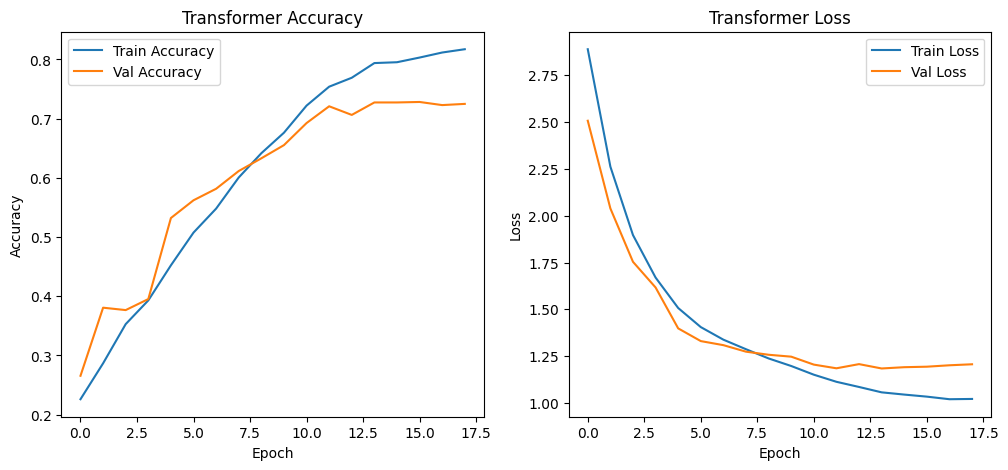

In [15]:
# Print final validation accuracy and loss for Transformer
final_val_acc = history_transformer.history['val_accuracy'][-1]
final_val_loss = history_transformer.history['val_loss'][-1]

print("Transformer Validation Accuracy:", final_val_acc)
print("Transformer Validation Loss:", final_val_loss)

# Optional: plot accuracy and loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_transformer.history['accuracy'], label='Train Accuracy')
plt.plot(history_transformer.history['val_accuracy'], label='Val Accuracy')
plt.title("Transformer Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_transformer.history['loss'], label='Train Loss')
plt.plot(history_transformer.history['val_loss'], label='Val Loss')
plt.title("Transformer Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [16]:
# ---------------------------
# Prepare test data (once)
# ---------------------------
df_test = pd.read_csv("test.csv")  # read test file once
X_test = df_test['text'].apply(clean_text)  # clean text
X_test_seq = tokenizer.texts_to_sequences(X_test)  # convert to sequences
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')  # pad sequences


In [17]:
# ---------------------------
# Custom Transformer Test Predictions
# ---------------------------
pred_probs_trans = model_custom_transformer.predict(X_test_pad)
pred_classes_trans = pred_probs_trans.argmax(axis=1)
pred_labels_trans = le.inverse_transform(pred_classes_trans)

df_test['review'] = pred_labels_trans
df_test[['id','review']].to_csv("test_predictions_custom_transformer.csv", index=False)


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [18]:
# ---------------------------
# CNN Test Predictions
# ---------------------------
pred_probs_cnn = model_cnn.predict(X_test_pad)
pred_classes_cnn = pred_probs_cnn.argmax(axis=1)
pred_labels_cnn = le.inverse_transform(pred_classes_cnn)

df_test['review'] = pred_labels_cnn
df_test[['id','review']].to_csv("test_predictions_cnn.csv", index=False)


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
